In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
# Load feature engineered dataset

df = pd.read_csv("outputs/space_missions_feature_engineered.csv")

df.head()

,Company,Location,Date,Time,Rocket,Mission,RocketStatus,Price,MissionStatus,Launch_DateTime,Launch_Year,Launch_Month,Launch_Month_Name,Launch_Quarter,Launch_Day,Launch_Day_Name,Launch_Week,Launch_Decade,Launch_Hour,Launch_Minute,Launch_Second,Launch_Period,Country,Launch_Site,Price_Category,Mission_Result,Rocket_Availability
0,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",04-10-1957,19:28:00,Sputnik 8K71PS,Sputnik-1,Retired,108.84232,Success,1957-10-04 19:28:00,1957,10,October,4,4,Friday,40,1950,19,28,0,Evening,Kazakhstan,Site 1/5,Premium,Successful,Retired
1,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",03-11-1957,2:30:00,Sputnik 8K71PS,Sputnik-2,Retired,108.84232,Success,1957-11-03 02:30:00,1957,11,November,4,3,Sunday,44,1950,2,30,0,Night,Kazakhstan,Site 1/5,Premium,Successful,Retired
2,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",06-12-1957,16:44:00,Vanguard,Vanguard TV3,Retired,108.84232,Failure,1957-12-06 16:44:00,1957,12,December,4,6,Friday,49,1950,16,44,0,Afternoon,USA,LC-18A,Premium,Unsuccessful,Retired
3,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",01-02-1958,3:48:00,Juno I,Explorer 1,Retired,108.84232,Success,1958-02-01 03:48:00,1958,2,February,1,1,Saturday,5,1950,3,48,0,Night,USA,LC-26A,Premium,Successful,Retired
4,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",05-02-1958,7:33:00,Vanguard,Vanguard TV3BU,Retired,108.84232,Failure,1958-02-05 07:33:00,1958,2,February,1,5,Wednesday,6,1950,7,33,0,Morning,USA,LC-18A,Premium,Unsuccessful,Retired


In [3]:
# Convert Launch_DateTime into datetime

df["Launch_DateTime"] = pd.to_datetime(df["Launch_DateTime"])

In [4]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4503 entries, 0 to 4502
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Company              4503 non-null   object        
 1   Location             4503 non-null   object        
 2   Date                 4503 non-null   object        
 3   Time                 4503 non-null   object        
 4   Rocket               4503 non-null   object        
 5   Mission              4503 non-null   object        
 6   RocketStatus         4503 non-null   object        
 7   Price                4503 non-null   float64       
 8   MissionStatus        4503 non-null   object        
 9   Launch_DateTime      4503 non-null   datetime64[ns]
 10  Launch_Year          4503 non-null   int64         
 11  Launch_Month         4503 non-null   int64         
 12  Launch_Month_Name    4503 non-null   object        
 13  Launch_Quarter       4503 non-nul

In [5]:
# Create company vs mission status table

company_status = pd.crosstab(
    df["Company"],
    df["MissionStatus"]
)

company_status.head()


MissionStatus,Failure,Partial Failure,Prelaunch Failure,Success
Company,,,,
AEB,1,0,0,0
AMBA,3,1,0,3
ASI,0,0,0,9
Arianespace,8,3,0,282
Armée de l'Air,0,1,0,3


In [6]:
# Display top companies by total launches

company_status["Total"] = company_status.sum(axis=1)

company_status.sort_values(
    by="Total",
    ascending=False
).head(10)

MissionStatus,Failure,Partial Failure,Prelaunch Failure,Success,Total
Company,,,,,
RVSN USSR,111,41,1,1564,1717
CASC,13,6,0,317,336
Arianespace,8,3,0,282,293
General Dynamics,35,11,0,203,249
VKS RF,8,6,0,199,213
NASA,11,6,0,186,203
SpaceX,5,4,1,172,182
US Air Force,26,2,0,129,157
ULA,0,1,0,150,151


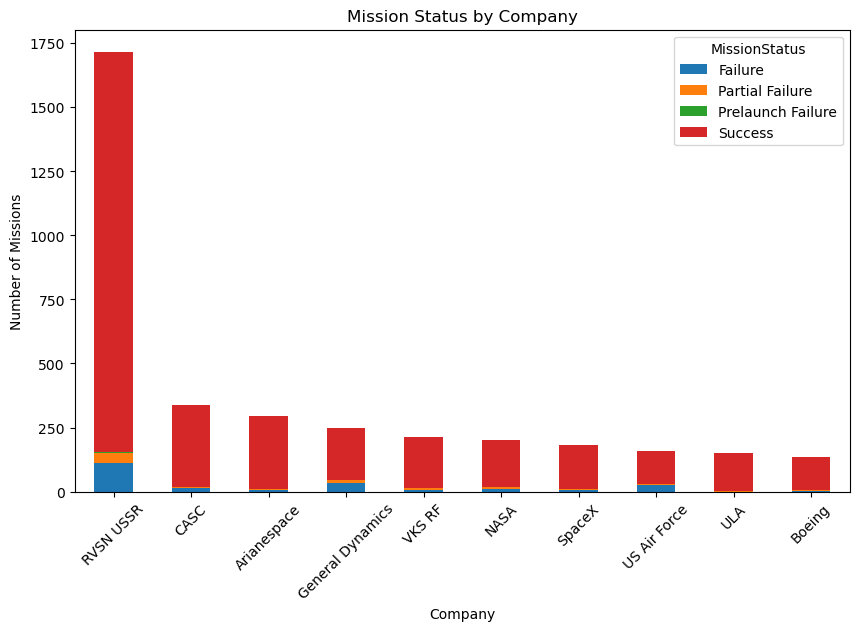

In [7]:
# Visualize top 10 companies

top_companies = company_status.sort_values(
    by="Total",
    ascending=False
).head(10)

top_companies.drop("Total", axis=1).plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Mission Status by Company")
plt.xlabel("Company")
plt.ylabel("Number of Missions")

plt.xticks(rotation=45)

plt.show()

In [8]:
# Create country vs mission status table

country_status = pd.crosstab(
    df["Country"],
    df["MissionStatus"]
)

country_status.head()

MissionStatus,Failure,Partial Failure,Prelaunch Failure,Success
Country,,,,
Australia,3,0,0,2
Barents Sea,1,0,0,2
Brazil,1,0,0,0
China,21,6,0,334
France,14,5,0,299


In [9]:
# Add total launches

country_status["Total"] = country_status.sum(axis=1)

country_status.sort_values(
    by="Total",
    ascending=False
).head(10)

MissionStatus,Failure,Partial Failure,Prelaunch Failure,Success,Total
Country,,,,,
USA,122,34,1,1287,1444
Russia,56,30,0,1286,1372
Kazakhstan,69,21,1,606,697
China,21,6,0,334,361
France,14,5,0,299,318
Japan,6,3,0,117,126
India,9,5,0,67,81
Pacific Ocean,3,0,0,29,32
New Zealand,3,0,0,25,28


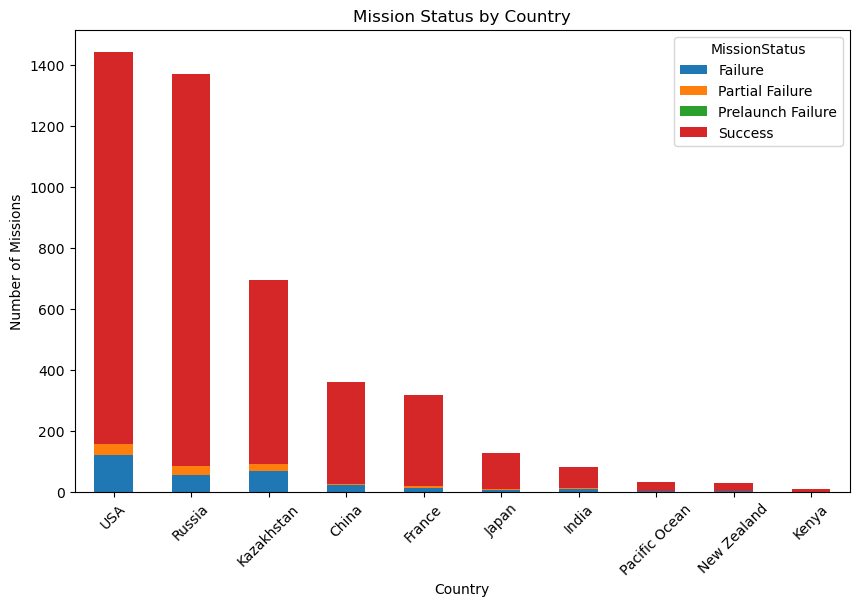

In [10]:
# Plot top 10 countries

top_country = country_status.sort_values(
    by="Total",
    ascending=False
).head(10)

top_country.drop("Total", axis=1).plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Mission Status by Country")
plt.xlabel("Country")
plt.ylabel("Number of Missions")

plt.xticks(rotation=45)

plt.show()

In [11]:
# Create rocket vs mission status table

rocket_status = pd.crosstab(
    df["Rocket"],
    df["MissionStatus"]
)

rocket_status.head()

MissionStatus,Failure,Partial Failure,Prelaunch Failure,Success
Rocket,,,,
ASLV,2,1,0,1
Angara 1.2,0,0,0,2
Angara A5/Briz-M,0,0,0,2
Angara A5/Persey,1,0,0,0
Antares 110,0,0,0,2


In [12]:
# Display top rockets

rocket_status["Total"] = rocket_status.sum(axis=1)

rocket_status.sort_values(
    by="Total",
    ascending=False
).head(10)

MissionStatus,Failure,Partial Failure,Prelaunch Failure,Success,Total
Rocket,,,,,
Cosmos-3M (11K65M),17,8,0,397,422
Voskhod,13,3,0,282,298
Molniya-M /Block ML,1,5,0,122,128
Cosmos-2I (63SM),7,0,0,118,125
Soyuz U,5,2,0,117,124
Tsyklon-3,5,3,0,109,117
Falcon 9 Block 5,0,0,0,111,111
Tsyklon-2,1,0,0,105,106
Vostok-2M,2,2,0,87,91


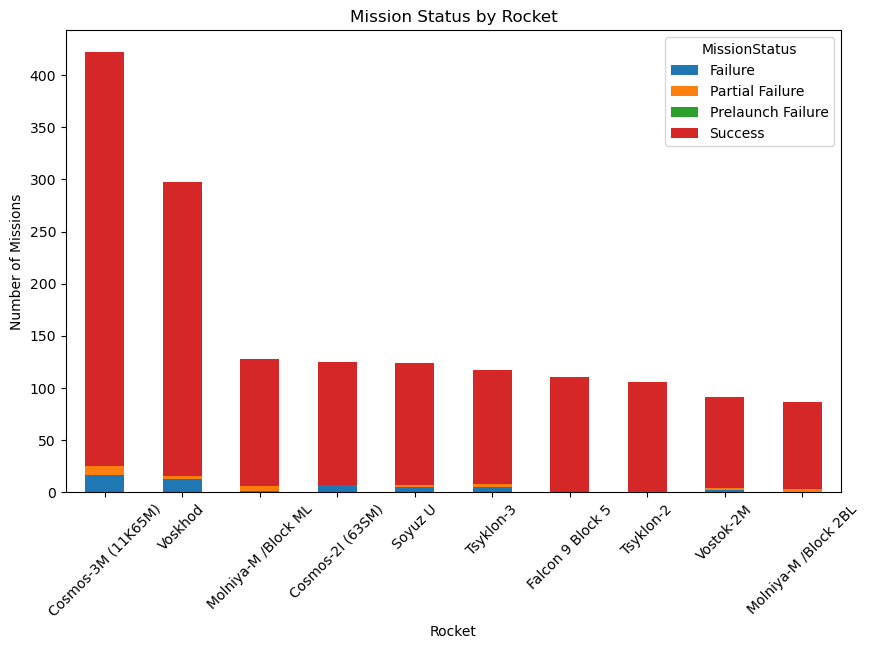

In [13]:
# Plot top rockets

top_rocket = rocket_status.sort_values(
    by="Total",
    ascending=False
).head(10)

top_rocket.drop("Total", axis=1).plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Mission Status by Rocket")
plt.xlabel("Rocket")
plt.ylabel("Number of Missions")

plt.xticks(rotation=45)

plt.show()